In [1]:
# ==========================================
# 1. Environment Setup & Imports
# ==========================================
%load_ext autoreload
%autoreload 2

import sys
import os
import gc
import json
from pathlib import Path
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Import Shared Utilities
# Robustly find analysis_utils.py whether running from Root or Subdir
current_dir = Path.cwd()
possible_paths = [
    current_dir,                                         # Case 1: CWD is Notebook Dir
    current_dir / "VisualScripts" / "ResultAnalysis",    # Case 2: CWD is Project Root
    Path(__file__).parent if '__file__' in locals() else current_dir # Case 3: Script execution
]

utils_path = None
for p in possible_paths:
    if (p / "analysis_utils.py").exists():
        utils_path = p
        if str(p) not in sys.path:
            sys.path.insert(0, str(p))
        print(f"[INFO] Found analysis_utils in: {p}")
        break

if utils_path is None:
    print("[WARN] analysis_utils.py not found in common paths. Please ensure it is accessible.")

try:
    import analysis_utils as utils
    from analysis_utils import PROJECT_ROOT
    print(f"Project Root: {PROJECT_ROOT}")
except ImportError as e:
    raise ImportError(f"Failed to import analysis_utils: {e}. Check if the file exists in {possible_paths}")

from Experiment.models import AccretionConvNet

[INFO] Found analysis_utils in: d:\PersonFiles\Codes\Project\MACNet v1\VisualScripts\ResultAnalysis
[INFO] Changed CWD to Project Root: d:\PersonFiles\Codes\Project\MACNet v1
d:\PersonFiles\Codes\Project\MACNet v1
Project Root: d:\PersonFiles\Codes\Project\MACNet v1


In [2]:
# ==========================================
# 2. Configuration
# ==========================================
# Experiment Settings
EXP_PREFIX = 'Exp6_AccretionConvNet'
DATA_PREFIX = 'Exp6_'
MODEL_PATH_OVERRIDE = None

# Paths
RESULTS_DIR = PROJECT_ROOT / 'Results'
CACHE_DIR   = PROJECT_ROOT / '.cache'

# Device
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {DEVICE}")

# Plotting
FIG_DIR_NAME = 'figures'

Using device: cuda


In [3]:
# ==========================================
# 3. Load Data & Model
# ==========================================
def _parse_stage_depths(value):
    if value is None:
        return (2, 2, 2, 2)
    if isinstance(value, (list, tuple)):
        return tuple(int(v) for v in value)
    if isinstance(value, str):
        cleaned = value.strip().strip('()[]')
        if not cleaned:
            return (2, 2, 2, 2)
        return tuple(int(v.strip()) for v in cleaned.split(',') if v.strip())
    return (2, 2, 2, 2)

def load_accretion_convnet(model_path, device, datasets_dict=None):
    model_path = Path(model_path)
    state = torch.load(model_path, map_location=device)
    raw_state = state.get('model', state.get('state_dict', state))

    # Infer input channels
    in_ch = 14
    if datasets_dict:
        ref_ds = next((ds for ds in datasets_dict.values() if ds is not None), None)
        if ref_ds:
            in_ch = int(ref_ds.x.shape[1])

    # Load hyperparameters if available
    params = {}
    config_path = model_path.parent / 'hyperparameters.json'
    if config_path.exists():
        try:
            with open(config_path, 'r', encoding='utf-8') as f:
                params = json.load(f)
        except Exception as exc:
            print(f"[WARN] Failed to read hyperparameters.json: {exc}")

    base_ch = int(params.get('base_ch', 64))
    stage_depths = _parse_stage_depths(params.get('stage_depths', (2, 2, 2, 2)))
    pos_num_bands = int(params.get('pos_num_bands', 32))
    pos_max_freq = float(params.get('pos_max_freq', 64.0))
    p_drop = float(params.get('p_drop', 0.1))
    se_reduction = int(params.get('se_reduction', 4))

    model = AccretionConvNet(
        c_in=in_ch,
        base_ch=base_ch,
        stage_depths=stage_depths,
        pos_num_bands=pos_num_bands,
        pos_max_freq=pos_max_freq,
        p_drop=p_drop,
        se_reduction=se_reduction,
    ).to(device)

    try:
        model.load_state_dict(raw_state, strict=True)
    except Exception:
        model.load_state_dict(raw_state, strict=False)

    model.eval()
    return model

# A. Load Cached Splits
splits = ['train', 'val', 'test']
datasets = {}
print('Loading cached datasets...')
for split in splits:
    pt_path = CACHE_DIR / f"{DATA_PREFIX}{split}.pt"
    if pt_path.exists():
        try:
            ds = utils.CachedPTDataset(pt_path)
            datasets[split] = ds
            print(f"  - [{split.upper()}] Loaded {len(ds)} samples ({ds.kind})")
        except Exception as e:
            print(f"  - [{split.upper()}] Failed to load: {e}")
            datasets[split] = None
    else:
        print(f"  - [{split.upper()}] Not found: {pt_path.name}")
        datasets[split] = None

# B. Find & Load Model
model_path = Path(MODEL_PATH_OVERRIDE) if MODEL_PATH_OVERRIDE else utils.find_latest_model(RESULTS_DIR, EXP_PREFIX)
if not model_path:
    raise RuntimeError(f"No model found for {EXP_PREFIX}")

print(f"Target Model: {model_path}")

model_type_display = None
pred_model_type = None
config_path = model_path.parent / 'hyperparameters.json'
model_cfg = {}
if config_path.exists():
    try:
        with open(config_path, 'r', encoding='utf-8') as f:
            model_cfg = json.load(f)
    except Exception as exc:
        print(f"[WARN] Failed to read hyperparameters.json: {exc}")

if model_cfg.get('model_type') == 'convnet':
    model = load_accretion_convnet(model_path, DEVICE, datasets)
    model_type_display = 'convnet'
    # ConvNet shares the AccretionTransformer input signature (x, r, theta, mbh)
    pred_model_type = 'vit'
else:
    model, model_type_display = utils.load_analysis_model(model_path, DEVICE, datasets)
    pred_model_type = model_type_display

print(f"Model Type: {model_type_display}")

# Setup Output Dir
output_dir = model_path.parent
fig_dir = output_dir / FIG_DIR_NAME
fig_dir.mkdir(parents=True, exist_ok=True)

# Data Save Dir for H5
data_save_dir = model_path.parent / 'prediction_data'
data_save_dir.mkdir(parents=True, exist_ok=True)
print(f"Prediction H5 data will be saved to: {data_save_dir}")

# Load normalization stats if available
norm_path = CACHE_DIR / f"{DATA_PREFIX}norm.npz"
norm_stats = None
if norm_path.exists():
    try:
        with np.load(norm_path) as data:
            norm_stats = {"mean": data["mean"], "std": data["std"]}
        print(f"Loaded normalization stats: {norm_path.name}")
    except Exception as exc:
        print(f"[WARN] Failed to load normalization stats: {exc}")
else:
    print(f"[WARN] Normalization stats not found: {norm_path.name}")

Loading cached datasets...
  - [TRAIN] Loaded 3000 samples (vit)
  - [VAL] Loaded 824 samples (vit)
  - [TEST] Loaded 828 samples (vit)
Target Model: d:\PersonFiles\Codes\Project\MACNet v1\Results\Exp6_AccretionConvNet20260210_004250\Exp6_AccretionConvNetbest_model.pth
Model Type: convnet
Prediction H5 data will be saved to: d:\PersonFiles\Codes\Project\MACNet v1\Results\Exp6_AccretionConvNet20260210_004250\prediction_data
Loaded normalization stats: Exp6_norm.npz


In [4]:
# ==========================================
# 4. Execution: Predictions
# ==========================================
all_results = {}

# A. Cached Train Set
if datasets['train']:
    print('Predicting on Cached Train Set...')
    # Request features for H5 saving
    df_train, feats, x_data = utils.predict_dataset(
        datasets['train'], model, DEVICE, pred_model_type, return_feats=True
    )
    
    # Use specific galaxy labels if available
    if 'type' not in df_train.columns or df_train['type'].iloc[0] == 'cached':
        df_train['type'] = 'Cached Train'
        
    all_results['train_cached'] = df_train
    
    # Save H5
    utils.save_to_h5(
        data_save_dir / f"{EXP_PREFIX}train_cached.h5", 
        df_train, feats, x_data, 'train_cached'
    )
    del feats, x_data
    gc.collect()

# B. Cached Test Set (In-Distribution)
if datasets['test']:
    print('Predicting on Cached Test Set (In-Dist)...')
    df_test, feats, x_data = utils.predict_dataset(
        datasets['test'], model, DEVICE, pred_model_type, return_feats=True
    )
    
    # Use specific galaxy labels if available
    if 'type' not in df_test.columns or df_test['type'].iloc[0] == 'cached':
        df_test['type'] = 'Cached In-Dist'
        
    all_results['test_cached'] = df_test
    
    # Save H5
    utils.save_to_h5(
        data_save_dir / f"{EXP_PREFIX}test_cached_indist.h5", 
        df_test, feats, x_data, 'test_cached_indist'
    )
    del feats, x_data; gc.collect()

# C. Cached Out-Of-Distribution (Held Out)
out_pt_path = CACHE_DIR / f"{DATA_PREFIX}out.pt"
if out_pt_path.exists():
    print(f"Predicting on Held-Out Test Set (Out-Dist): {out_pt_path.name}...")
    try:
        ds_out = utils.CachedPTDataset(out_pt_path)
        df_out, feats, x_data = utils.predict_dataset(
            ds_out, model, DEVICE, pred_model_type, return_feats=True
        )
        
        # Use specific galaxy labels if available
        if 'type' not in df_out.columns or df_out['type'].iloc[0] == 'cached':
            df_out['type'] = 'Cached Out-Dist'
            
        all_results['test_out'] = df_out
        
        # Save H5
        utils.save_to_h5(
            data_save_dir / f"{EXP_PREFIX}test_cached_outdist.h5", 
            df_out, feats, x_data, 'test_cached_outdist'
        )
        del feats, x_data; gc.collect()
    except Exception as e:
        print(f"  [Error] Failed to load Out-Dist: {e}")

# D. All Raw Datasets
RAW_MIRROR = True
list_dg = [
    'disk_galaxy_fiducial', 'disk_galaxy_supplement', 
    'disk_galaxy_fiducial_4', 'disk_galaxy_fiducial_7', 
    'disk_galaxy_fiducial_10', 'disk_galaxy_low'
]

raw_paths = []
if utils.Exp_dg_folder_paths:
    raw_paths = utils.Exp_dg_folder_paths
else:
    # Manual Fallback
    res = 'coarse'
    for fname in list_dg:
        p = PROJECT_ROOT / 'Data' / fname / res
        if p.exists():
            raw_paths.append((str(p), np.array([0,0])))

print(f"Processing {len(raw_paths)} Raw Datasets...")
dfs_raw = []
for p_conf in raw_paths:
    try:
        if norm_stats is not None:
            ds_raw = utils.HDF5Dataset(
                p_conf, mean=norm_stats["mean"], std=norm_stats["std"], mirror=RAW_MIRROR
            )
        else:
            ds_raw = utils.HDF5Dataset(p_conf, mirror=RAW_MIRROR)
        print(f"  > {ds_raw.type} ({len(ds_raw)})")
        
        df, feats, x_data = utils.predict_dataset(
            ds_raw, model, DEVICE, pred_model_type, return_feats=True
        )
        
        # Save H5
        utils.save_to_h5(
            data_save_dir / f"{ds_raw.type}.h5", 
            df, feats, x_data, ds_raw.type
        )
        
        dfs_raw.append(df)
        del feats, x_data; gc.collect()
    except Exception as e:
        print(f"  [Error] {p_conf}: {e}")

if dfs_raw:
    all_results['raw_all'] = pd.concat(dfs_raw, ignore_index=True)

# Save predictions as CSV (for quick inspection)
for k, df in all_results.items():
    s_path = output_dir / f"{k}_predictions.csv"
    df.to_csv(s_path, index=False)
    print(f"Saved: {s_path.name}")

Predicting on Cached Train Set...


Predicting on Cached Test Set (In-Dist)...
Processing 6 Raw Datasets...
  > disk_galaxy_fiducial (918)
  > disk_galaxy_supplement (896)
  > disk_galaxy_fiducial_4 (489)
  > disk_galaxy_fiducial_7 (527)
  > disk_galaxy_fiducial_10 (953)
  > disk_galaxy_low (945)
Saved: train_cached_predictions.csv
Saved: test_cached_predictions.csv
Saved: raw_all_predictions.csv


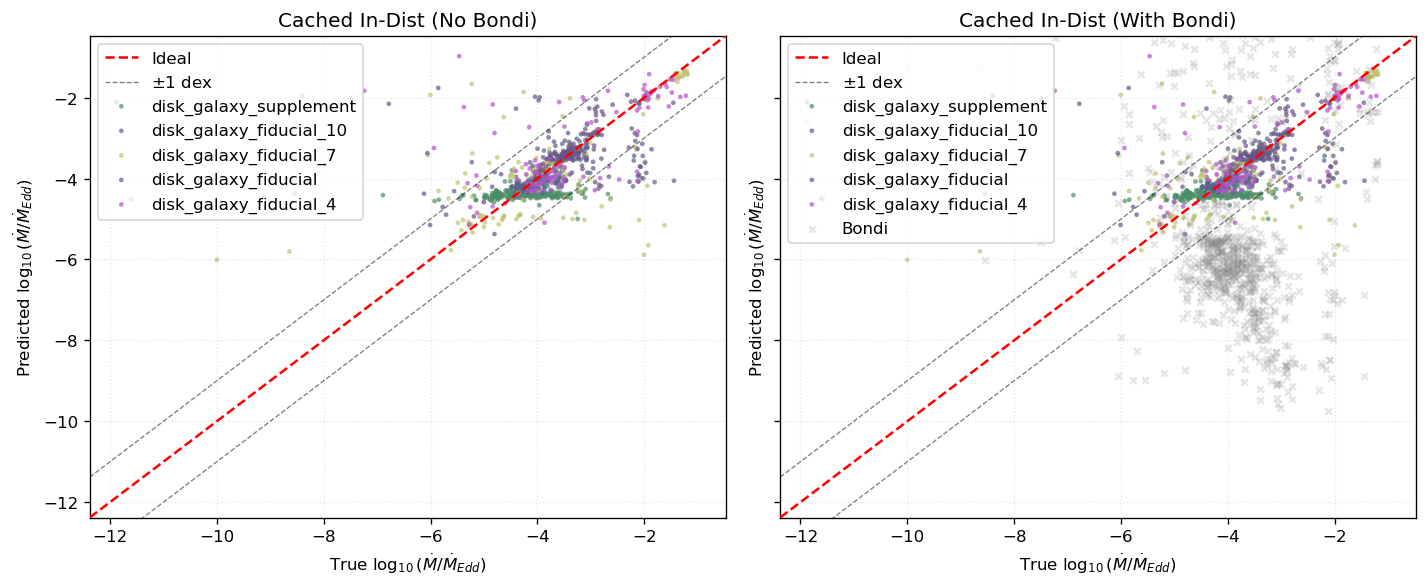

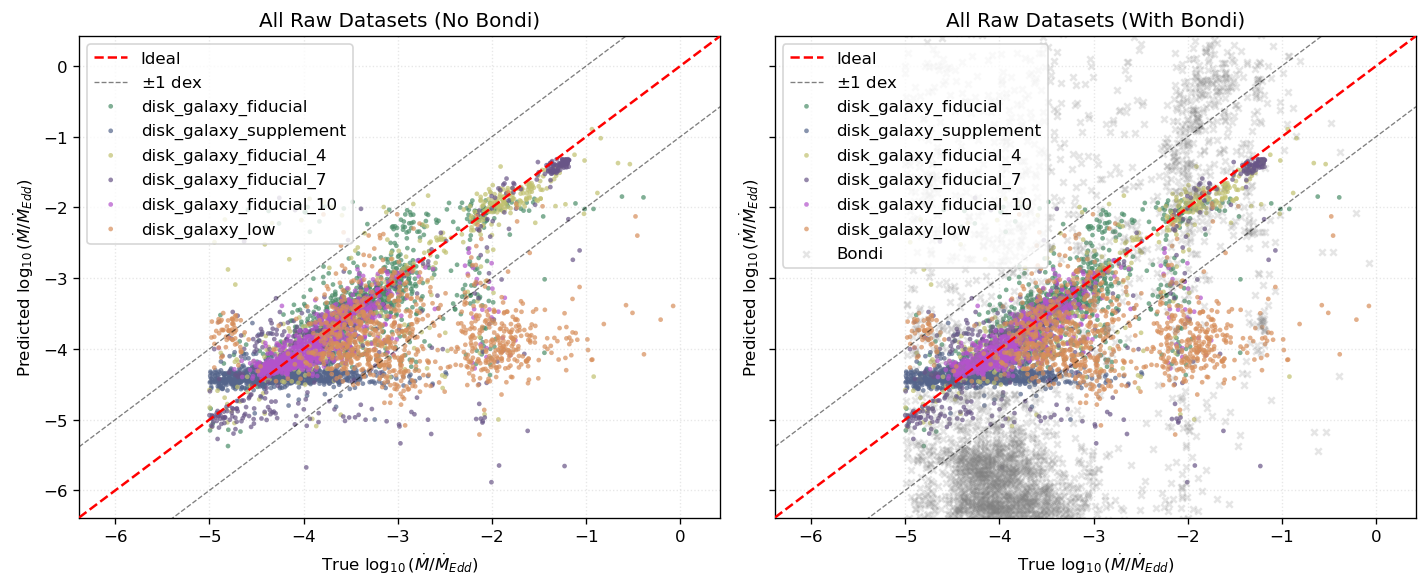

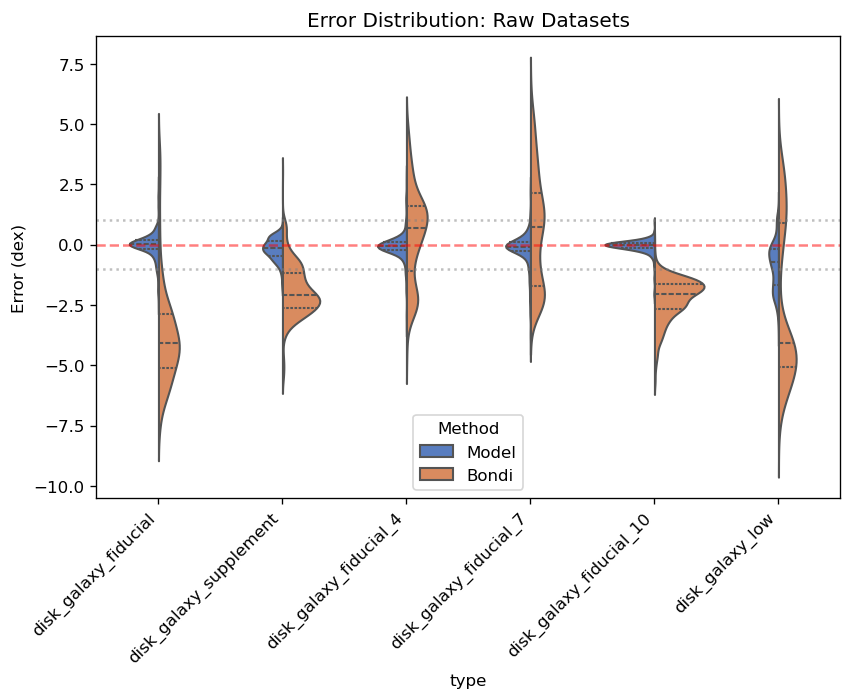

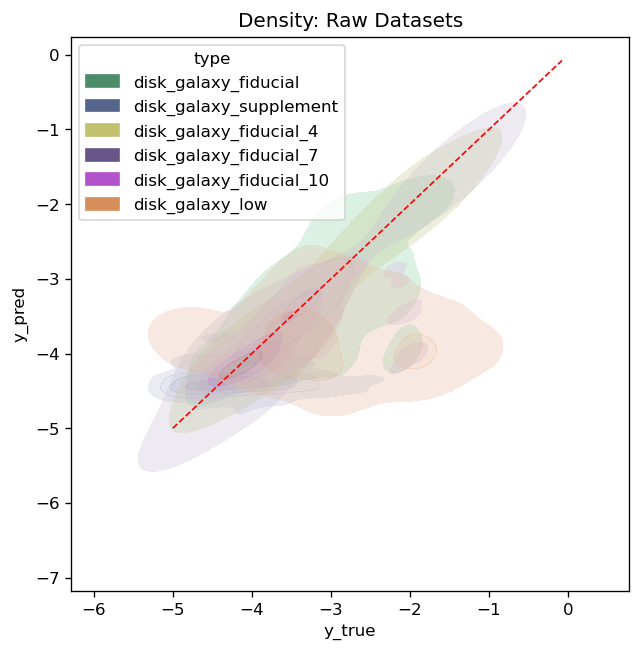

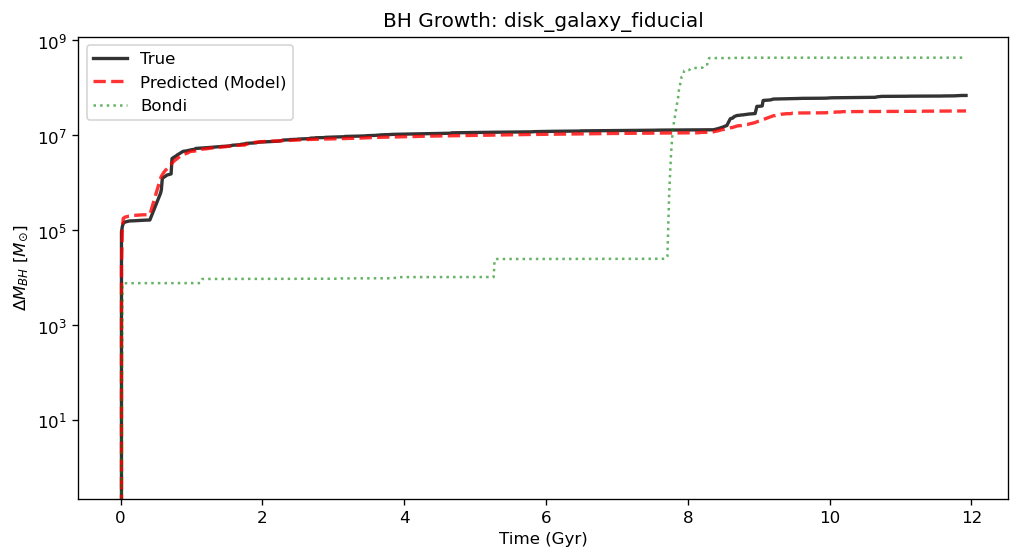

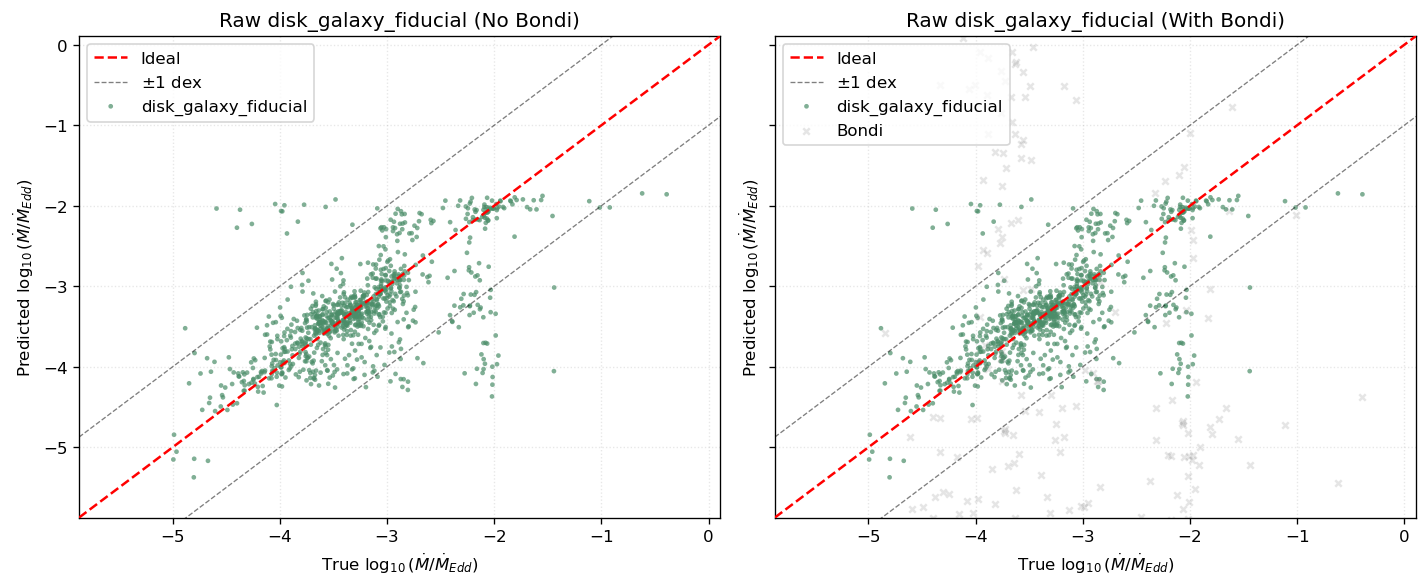

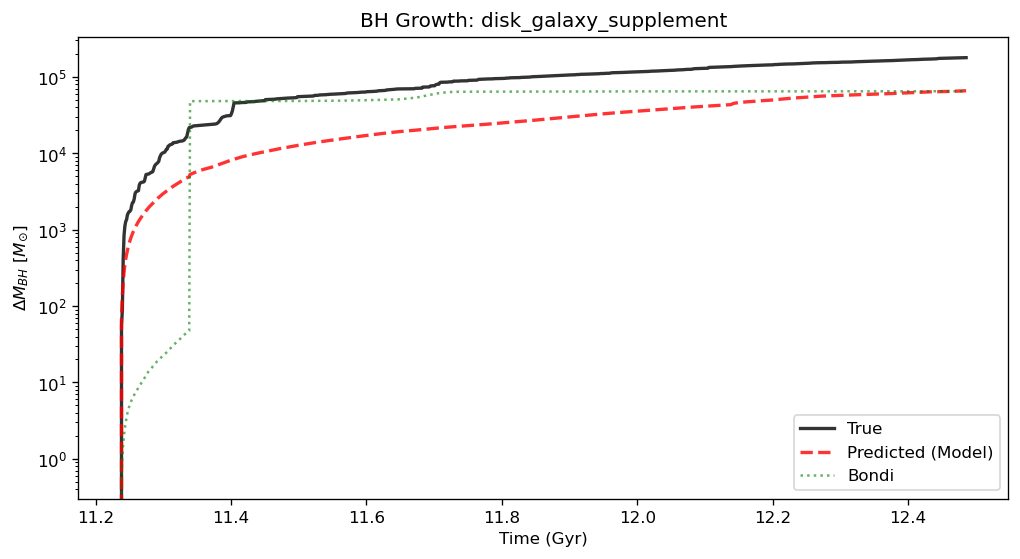

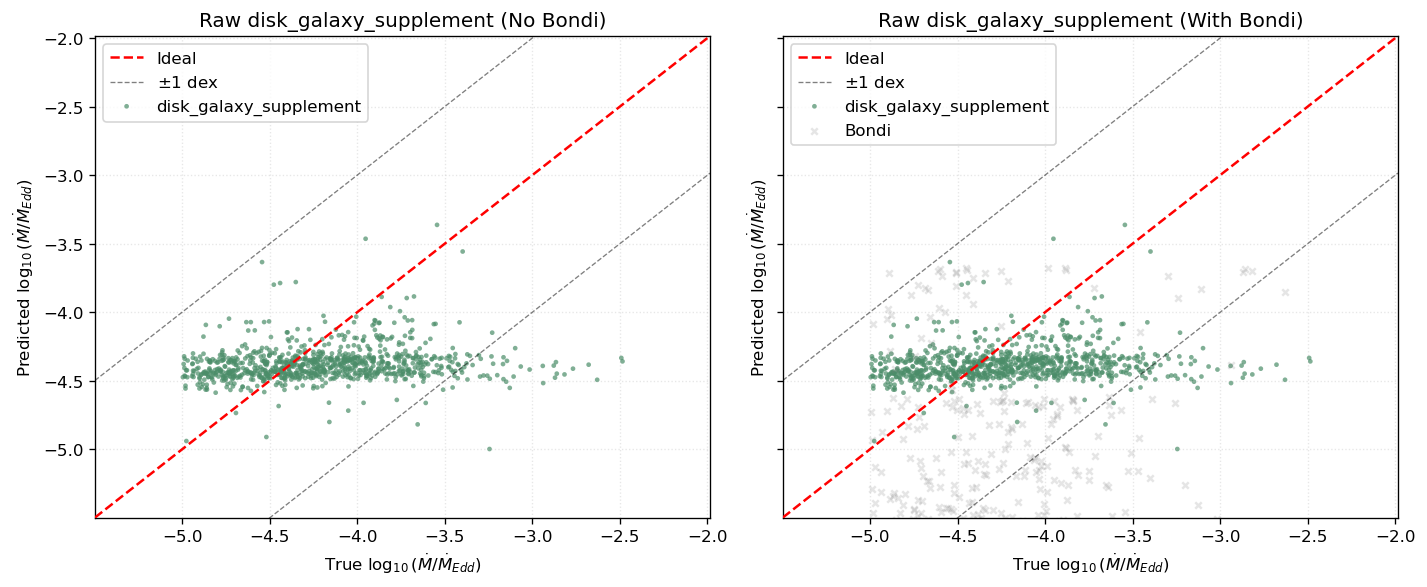

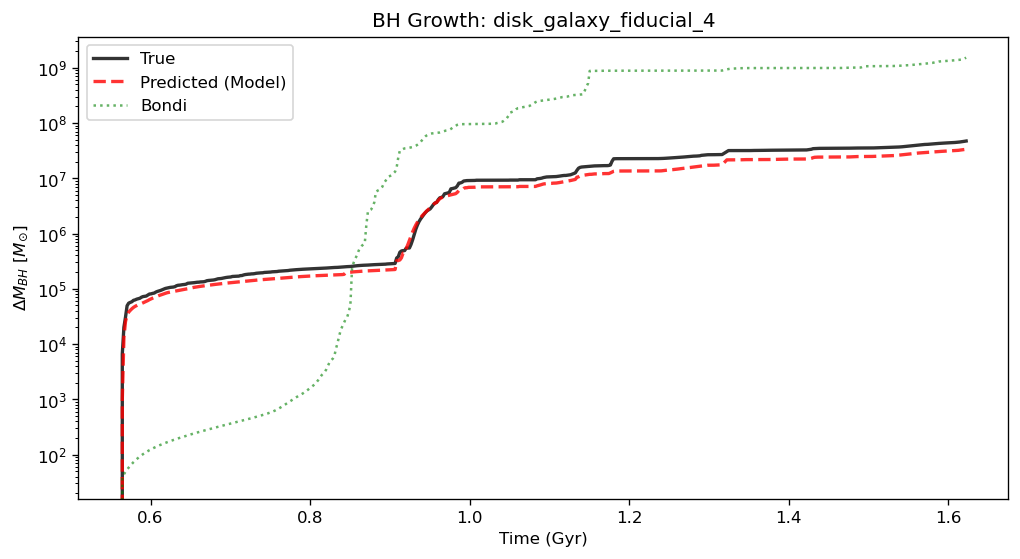

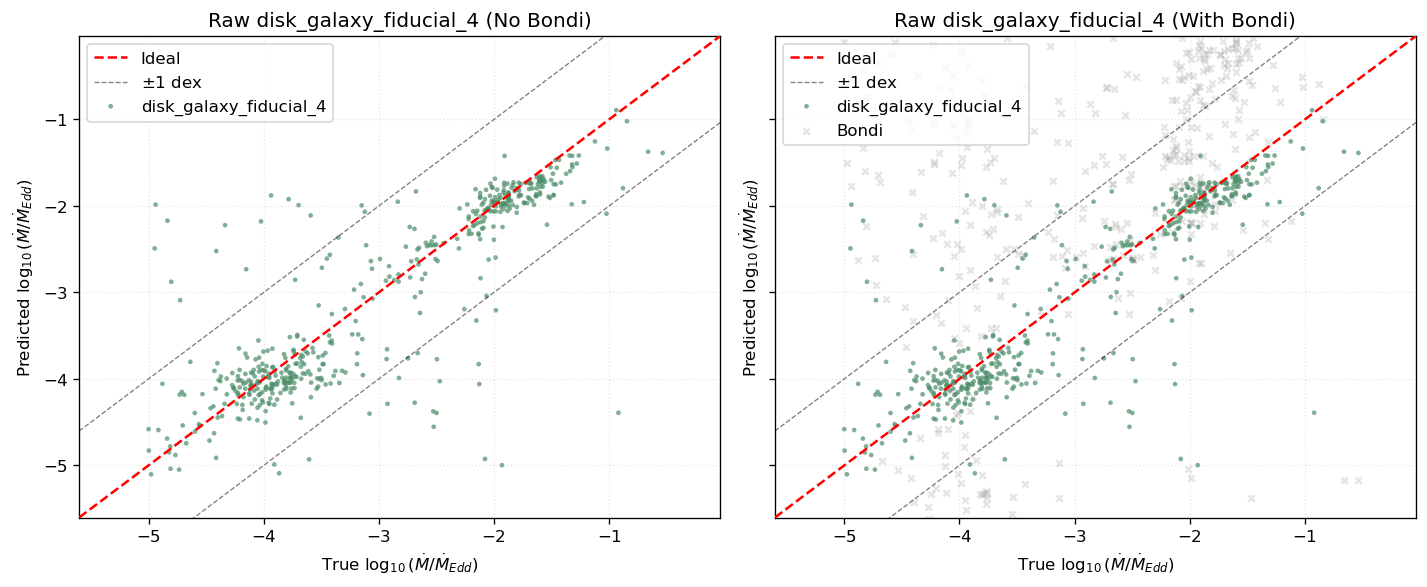

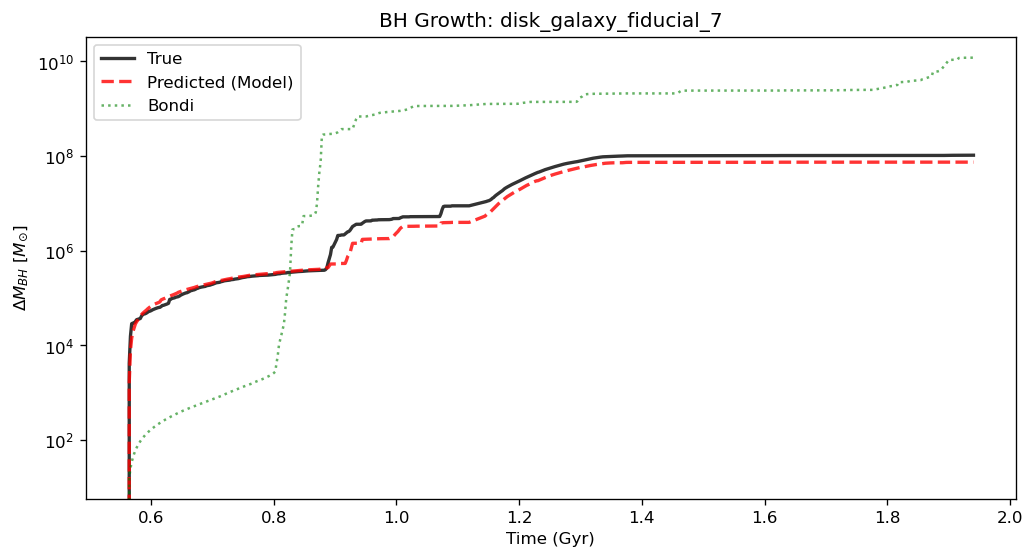

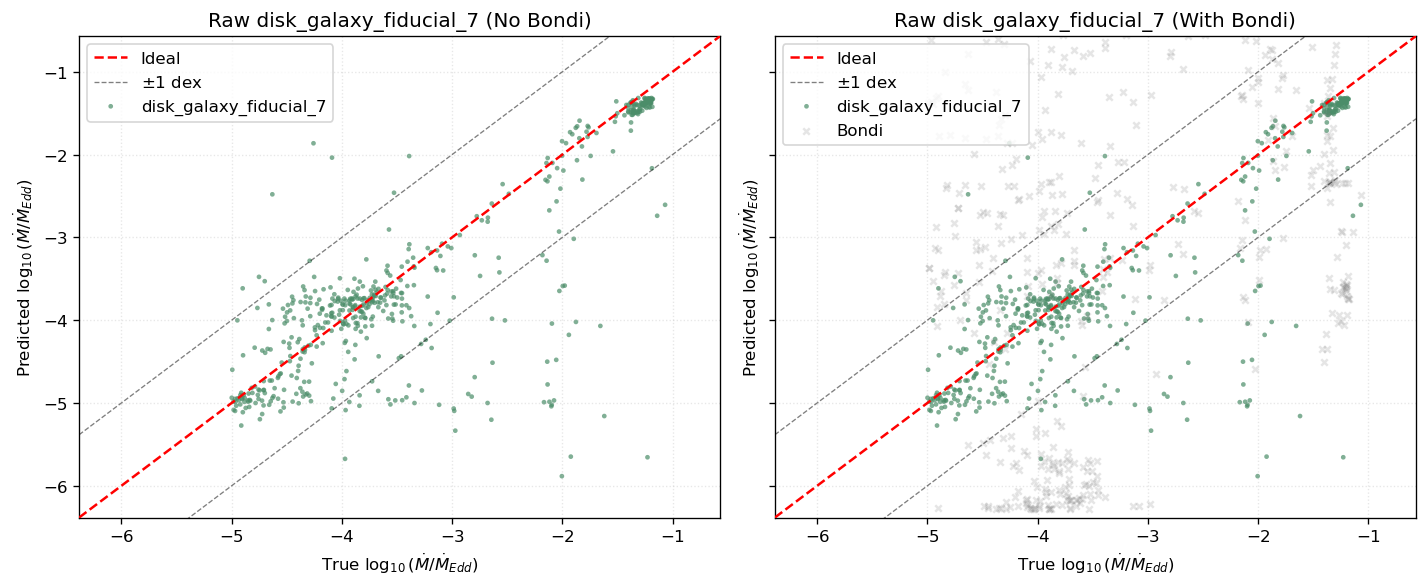

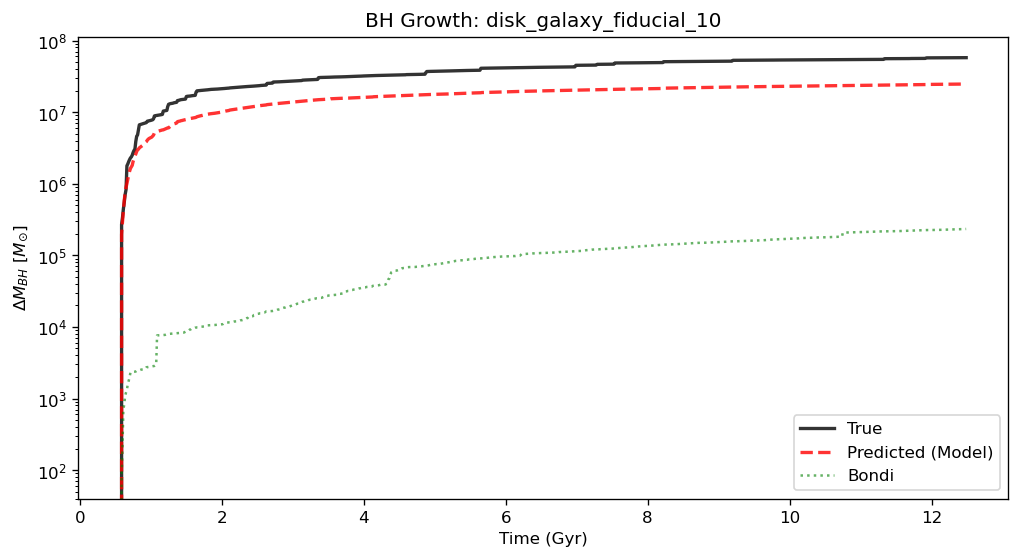

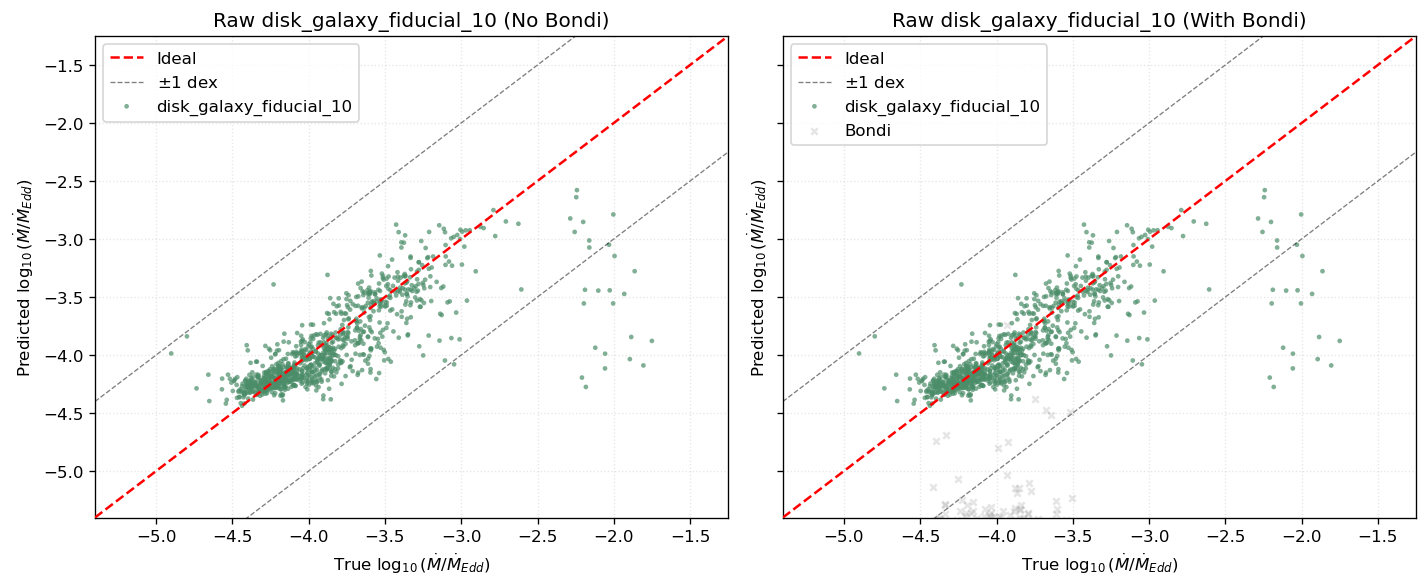

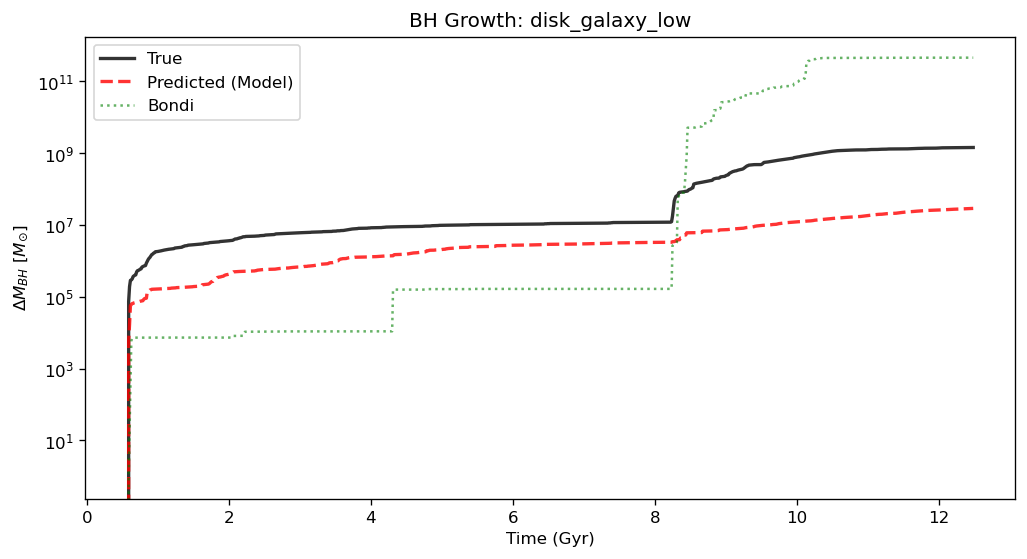

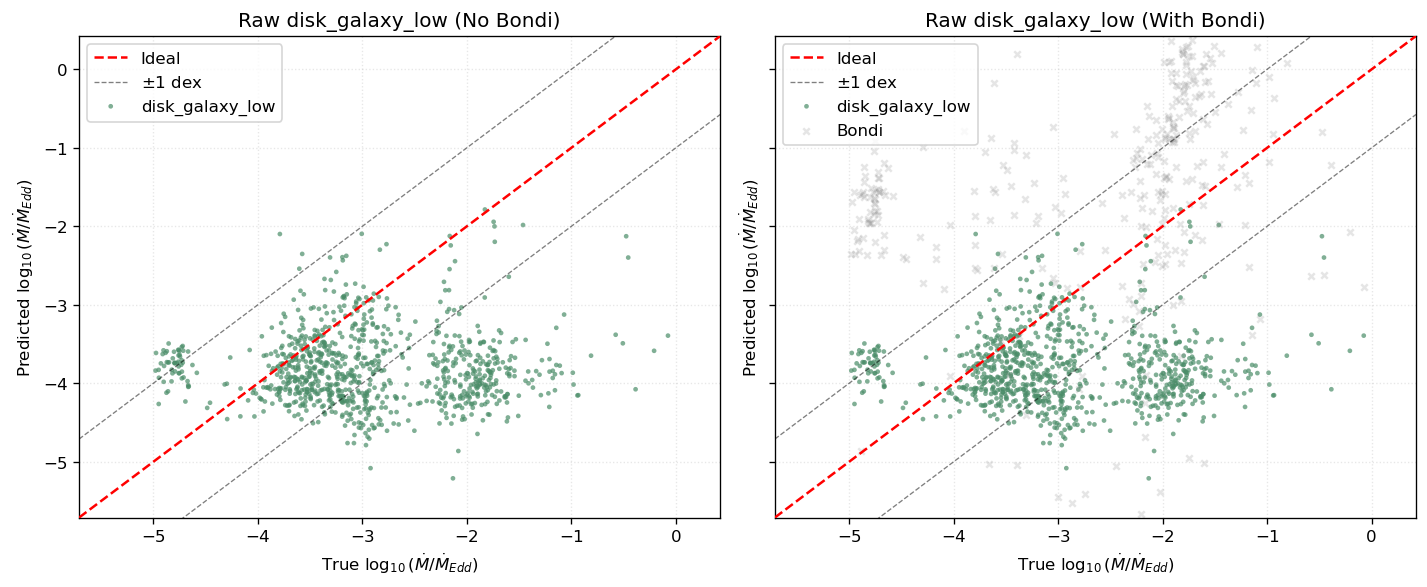

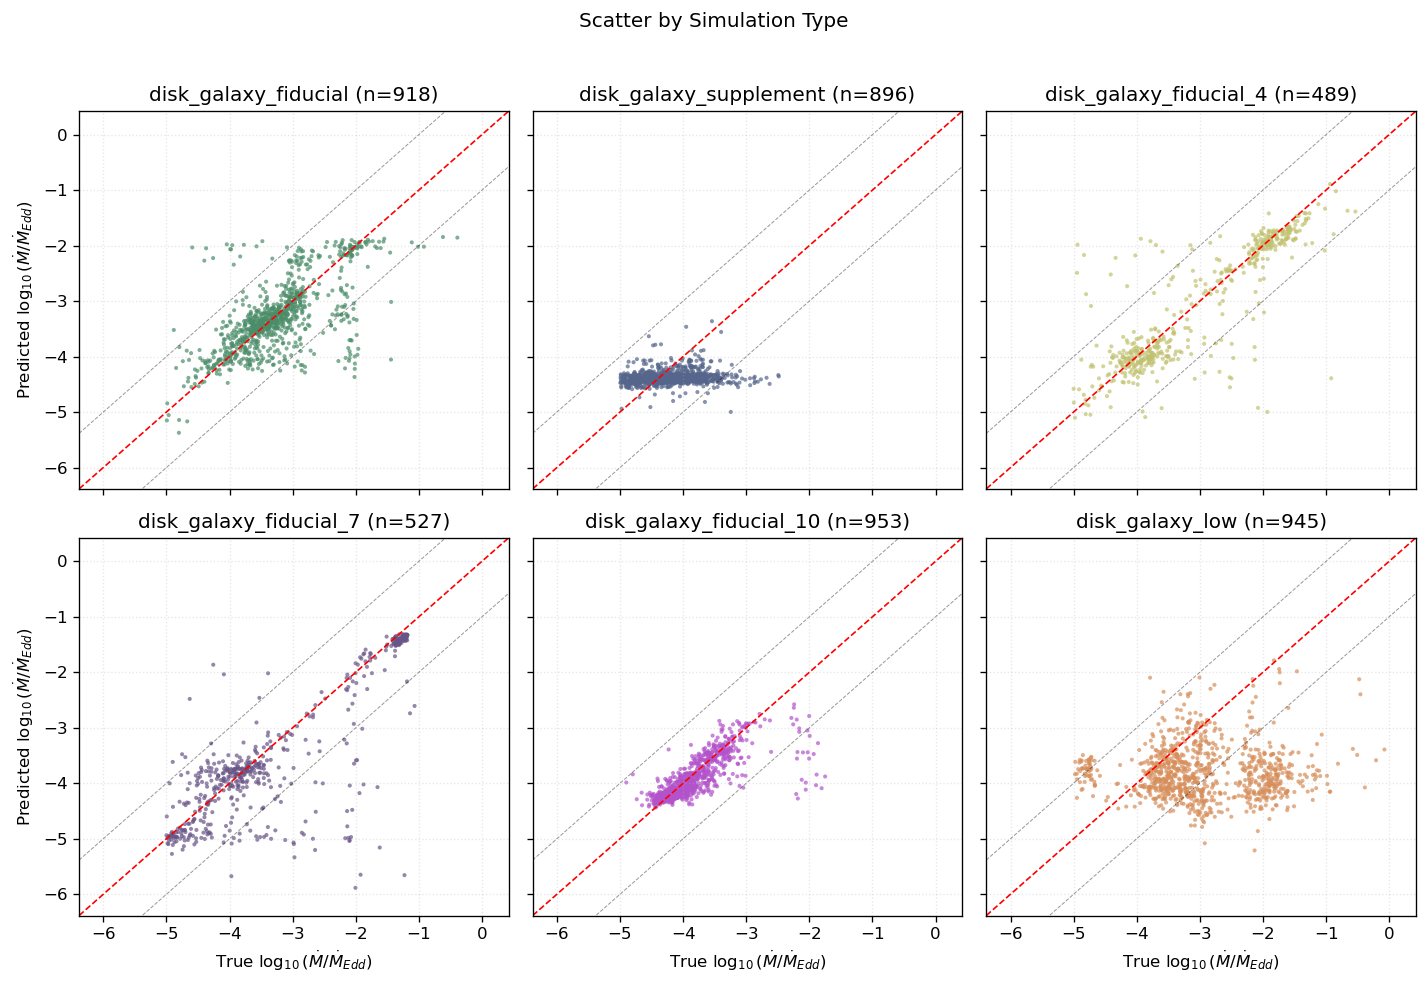

,Dataset,RMSE,MAE,R2,OutlierFrac (>1dex)
0,Cached In-Dist,1.004,0.519,0.192,13.285
1,Raw All (Model),0.756,0.467,0.314,13.811
2,Raw All (Bondi),3.184,2.747,-11.179,87.204
3,Type: disk_galaxy_fiducial,0.541,0.340,0.344,7.407
4,Type: disk_galaxy_supplement,0.495,0.382,-0.160,4.799
5,Type: disk_galaxy_fiducial_4,0.583,0.335,0.705,7.566
6,Type: disk_galaxy_fiducial_7,0.763,0.426,0.607,11.765
7,Type: disk_galaxy_fiducial_10,0.318,0.180,0.556,1.994
8,Type: disk_galaxy_low,1.318,1.052,-1.211,44.868


In [5]:
# ==========================================
# 5. Visualization & Metrics
# ==========================================
metrics_list = []

# 1. Cached Test (In-Dist)
if 'test_cached' in all_results:
    df = all_results['test_cached']
    metrics_list.append(utils.get_metrics_summary(df['y_true'], df['y_pred'], 'Cached In-Dist'))
    utils.plot_scatter(df, 'Cached In-Dist', fig_dir)

# 2. Cached Test (Out-Dist)
if 'test_out' in all_results:
    df = all_results['test_out']
    metrics_list.append(utils.get_metrics_summary(df['y_true'], df['y_pred'], 'Cached Out-Dist'))
    utils.plot_scatter(df, 'Cached Out-Dist', fig_dir)

# 3. Raw Data
if 'raw_all' in all_results:
    df_raw = all_results['raw_all']
    metrics_list.append(utils.get_metrics_summary(df_raw['y_true'], df_raw['y_pred'], 'Raw All (Model)'))
    
    if 'y_bondi' in df_raw.columns:
         valid_b = df_raw.dropna(subset=['y_bondi'])
         metrics_list.append(utils.get_metrics_summary(valid_b['y_true'], valid_b['y_bondi'], 'Raw All (Bondi)'))

    utils.plot_scatter(df_raw, 'All Raw Datasets', fig_dir)
    utils.plot_error_dist(df_raw, 'Raw Datasets', fig_dir)
    utils.plot_kde_contour(df_raw, 'Raw Datasets', fig_dir)
    
    # Per Galaxy Type
    for t in df_raw['type'].unique():
        sub = df_raw[df_raw['type'] == t]
        metrics_list.append(utils.get_metrics_summary(sub['y_true'], sub['y_pred'], f'Type: {t}'))
        utils.plot_mass_evolution(sub, t, fig_dir)
        # Scatter per simulation/type
        if len(sub) > 1:
            utils.plot_scatter(sub, f'Raw {t}', fig_dir)
    
    # Scatter grid by type (3 columns)
    types = list(df_raw['type'].unique())
    if types:
        ncols = 3
        nrows = int(np.ceil(len(types) / ncols))
        fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 4 * nrows), dpi=120, sharex=True, sharey=True)
        axes = np.atleast_1d(axes).flatten()
        vmin = min(df_raw['y_true'].min(), df_raw['y_pred'].min()) - 0.5
        vmax = max(df_raw['y_true'].max(), df_raw['y_pred'].max()) + 0.5
        for i, t in enumerate(types):
            ax = axes[i]
            sub = df_raw[df_raw['type'] == t]
            ax.plot([vmin, vmax], [vmin, vmax], 'r--', lw=1)
            ax.plot([vmin, vmax], [vmin - 1, vmax - 1], 'k--', lw=0.6, alpha=0.4)
            ax.plot([vmin, vmax], [vmin + 1, vmax + 1], 'k--', lw=0.6, alpha=0.4)
            ax.scatter(
                sub['y_true'], sub['y_pred'],
                s=6, alpha=0.7, color=utils.COLORS[i % len(utils.COLORS)], edgecolors='none'
            )
            ax.set_title(f"{t} (n={len(sub)})")
            ax.grid(True, linestyle=':', alpha=0.3)
        for j in range(len(types), len(axes)):
            axes[j].axis('off')
        for ax in axes:
            ax.set_xlim(vmin, vmax)
            ax.set_ylim(vmin, vmax)
            ax.set_xlabel("")
            ax.set_ylabel("")
        for ax in axes[::ncols]:
            ax.set_ylabel(r"Predicted $\log_{10}(\dot{M}/\dot{M}_{Edd})$")
        for ax in axes[-ncols:]:
            ax.set_xlabel(r"True $\log_{10}(\dot{M}/\dot{M}_{Edd})$")
        fig.suptitle('Scatter by Simulation Type', y=1.02)
        fig.tight_layout()
        utils.save_plot(plt, 'scatter_by_type_grid', fig_dir)
        plt.show()

# 4. Summary Table
metrics_df = pd.DataFrame(metrics_list)
pd.options.display.float_format = '{:,.3f}'.format
display(metrics_df)
metrics_df.to_csv(output_dir / 'summary_metrics.csv', index=False)

In [6]:
# ==========================================
# 6. Save Markdown Report
# ==========================================
md_path = output_dir / 'summary_metrics.md'
with open(md_path, 'w', encoding='utf-8') as f:
    f.write(f"# Analysis Results: {EXP_PREFIX}\n\n")
    f.write(f"- **Model**: `{model_path.name}`\n")
    f.write(f"- **Type**: `{model_type_display}`\n\n")
    
    f.write('## Metrics\n')
    f.write(metrics_df.to_markdown(floatfmt='3f'))
    
    f.write('\n\n## Visualizations\n')
    for img in sorted(fig_dir.glob(f'*.png')):
        f.write(f"### {img.stem}\n![{img.stem}]({FIG_DIR_NAME}/{img.name})\n\n")
        
print(f"Saved report to {md_path}")

Saved report to d:\PersonFiles\Codes\Project\MACNet v1\Results\Exp6_AccretionConvNet20260210_004250\summary_metrics.md


,set,count,mean,std,q05,q50,q95
0,train_cached,3000,-3.703,1.114,-5.264,-3.854,-1.606
1,test_cached,828,-3.805,1.118,-5.269,-3.866,-1.923
2,raw_all,4728,-3.470,0.913,-4.726,-3.649,-1.690


,set,bias_mean,bias_median,err_q05,err_q50,err_q95
0,train_cached,-0.014,-0.028,-0.626,-0.028,0.513
1,test_cached,0.019,-0.022,-1.278,-0.022,1.235
2,raw_all,-0.263,-0.096,-1.879,-0.096,0.535


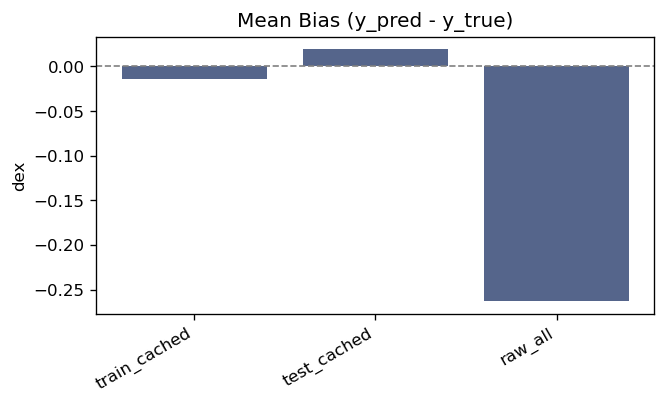

In [7]:
# ==========================================
# 4b. Bias Diagnostics (Distribution & Offset)
# ==========================================
def _summarize_target(name, series):
    q = series.quantile([0.05, 0.5, 0.95]).to_dict()
    return {
        "set": name,
        "count": int(series.shape[0]),
        "mean": float(series.mean()),
        "std": float(series.std()),
        "q05": float(q.get(0.05, np.nan)),
        "q50": float(q.get(0.5, np.nan)),
        "q95": float(q.get(0.95, np.nan)),
    }

def _summarize_bias(name, df):
    err = df["y_pred"] - df["y_true"]
    q = err.quantile([0.05, 0.5, 0.95]).to_dict()
    return {
        "set": name,
        "bias_mean": float(err.mean()),
        "bias_median": float(err.median()),
        "err_q05": float(q.get(0.05, np.nan)),
        "err_q50": float(q.get(0.5, np.nan)),
        "err_q95": float(q.get(0.95, np.nan)),
    }

target_rows = []
bias_rows = []

if "train_cached" in all_results:
    target_rows.append(_summarize_target("train_cached", all_results["train_cached"]["y_true"]))
    bias_rows.append(_summarize_bias("train_cached", all_results["train_cached"]))
if "test_cached" in all_results:
    target_rows.append(_summarize_target("test_cached", all_results["test_cached"]["y_true"]))
    bias_rows.append(_summarize_bias("test_cached", all_results["test_cached"]))
if "test_out" in all_results:
    target_rows.append(_summarize_target("test_out", all_results["test_out"]["y_true"]))
    bias_rows.append(_summarize_bias("test_out", all_results["test_out"]))
if "raw_all" in all_results:
    target_rows.append(_summarize_target("raw_all", all_results["raw_all"]["y_true"]))
    bias_rows.append(_summarize_bias("raw_all", all_results["raw_all"]))

if target_rows:
    target_df = pd.DataFrame(target_rows)
    pd.options.display.float_format = '{:,.3f}'.format
    display(target_df)
    target_df.to_csv(output_dir / "target_stats.csv", index=False)

if bias_rows:
    bias_df = pd.DataFrame(bias_rows)
    pd.options.display.float_format = '{:,.3f}'.format
    display(bias_df)
    bias_df.to_csv(output_dir / "bias_stats.csv", index=False)

# Quick scatter of mean bias by dataset
if bias_rows:
    try:
        plt.figure(figsize=(6, 3), dpi=120)
        plt.bar(bias_df["set"], bias_df["bias_mean"], color="#55658B")
        plt.axhline(0, color="gray", linestyle="--", linewidth=1)
        plt.title("Mean Bias (y_pred - y_true)")
        plt.ylabel("dex")
        plt.xticks(rotation=30, ha="right")
        utils.save_plot(plt, "mean_bias_by_set", fig_dir)
        plt.show()
    except Exception as exc:
        print(f"[WARN] Failed to plot bias summary: {exc}")